In [1]:
import awkward as ak

## Comparing MC scaling between JZ2 and JZ4

Ignoring JZ3 for now - though it needs to be rescalled as well - just because JZ2 should have a very large rescalling factor, and JZ4 should comparatively be lower.

Equation for the rescaling is:

$$v_i = \frac{w_i}{N} \left( \epsilon \cdot L \cdot k \cdot \sigma \right)$$

Where the variables are defined as 
- $w_i$, original un-normalized MC event weight
- $N$, the normalization of the sample (for JZ slices, this is the sum of all un-normalized MC event weights)
- $\sigma$, the inclusive cross-section of the simulated process
- $L_i$, the integrated luminosity of the dataset campaign (e.g. 26 $fb^{-1}$ for MC23a)
- $\epsilon$, the selection efficiency of event filter(s) applied during the event generation chain

These values can be found using AMI. The definition of normalization taken from the [jetetmiss group documentations](https://atlas-jetetmiss.docs.cern.ch/users/QCD-samples/)

In [9]:
dfjz2 = ak.from_parquet("../jz2_000.parquet")
dfjz4 = ak.from_parquet("../jz4_000.parquet")

In [11]:
len(dfjz4)

65478

Scaling factors for JZ2

In [3]:
N = sum(dfjz2.mcEventWeight)
sigma = 2.58E12 # fb
# lumi = 26 #fb^-1
eps = 0.01006532
scale_jz2 = sigma * eps / N
print(f'{scale_jz2:e}')

7.474955e+11


Scaling factor for JZ4

In [4]:
N = sum(dfjz4.mcEventWeight)
sigma = 2.8E8
# lumi = 26
eps = 0.01374964
scale_jz4 = sigma * eps/N
print(scale_jz4)

2.3053469e+08


Now have to multiply the mcEventWeight column by the corresponding scale factors, and then use that as the weight when plotting

In [5]:
jz2_weights = dfjz2.mcEventWeight * scale_jz2
jz4_weights = dfjz4.mcEventWeight * scale_jz4
comb_weights = ak.concatenate([jz2_weights[:1], jz4_weights])

In [6]:
comb_jz2jz4 = ak.concatenate([dfjz2[:1], dfjz4])

In [7]:
import matplotlib.pyplot as plt

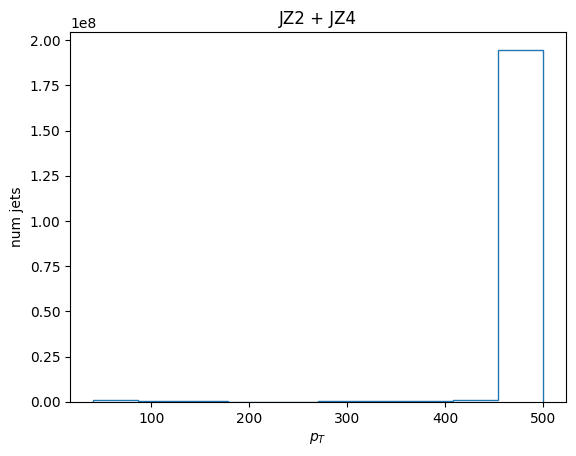

In [8]:
# plt.hist(dfjz2.pt, histtype='step', weights=jz2_weights)
# plt.hist(dfjz4.pt, histtype='step', weights=jz4_weights)
plt.hist(comb_jz2jz4.pt, histtype='step', weights=comb_weights)
plt.xlabel("$p_T$")
plt.ylabel("num jets")
plt.title("JZ2 + JZ4")
# plt.hist(qcddf.pt, density=True, histtype='step')
plt.show()

Clearly something going on with the weighting. Not sure if this is due to the fact that the reweighting is only done on a small subset of the datasets, and if we include more of the datasets they'll look more normal. Should try this again with the full datasets probably and see what the result looks like.

Pulling in larger datasets to plot them

In [9]:
ds_jz4_000_009 = ak.from_parquet("/data/agolub/bulk_processed_files/cr/jz4_000_009.parquet")

In [10]:
len(ds_jz4_000_009)

4000134

In [11]:
jz2_weights = dfjz2.mcEventWeight * scale_jz2
jz4_000_009_weights = ds_jz4_000_009.mcEventWeight * scale_jz4
comb_weights = ak.concatenate([jz2_weights, jz4_000_009_weights])

In [12]:
comb_jz4_000_009_jz2 = ak.concatenate([dfjz2,ds_jz4_000_009])

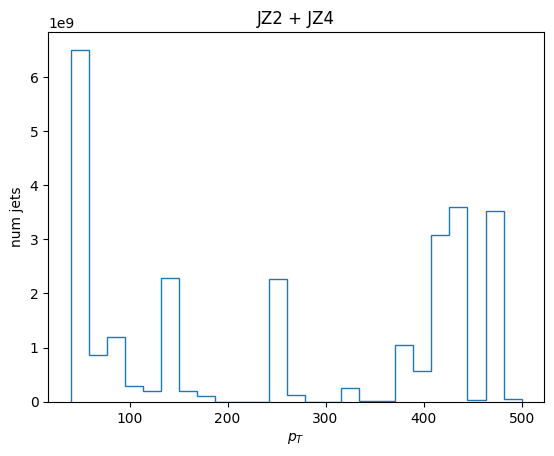

In [ ]:
# plt.hist(dfjz2.pt, histtype='step', weights=jz2_weights)
# plt.hist(dfjz4.pt, histtype='step', weights=jz4_weights)
plt.hist(comb_jz4_000_009_jz2.pt, histtype='step', weights=comb_weights, bins=25)
plt.xlabel("$p_T$")
plt.ylabel("num jets")
plt.title("JZ2 + JZ4, weighted")
# plt.hist(qcddf.pt, density=True, histtype='step')
plt.show()

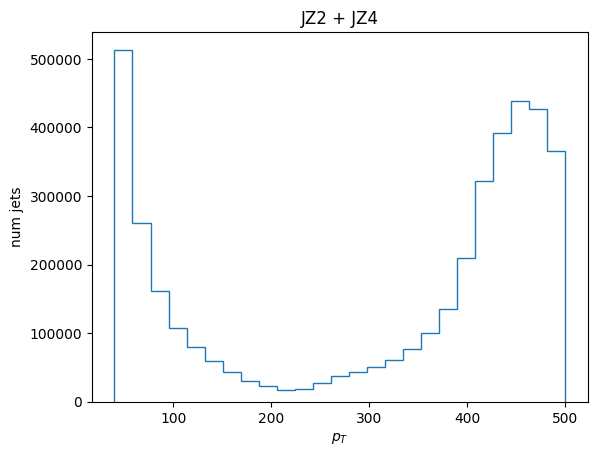

In [14]:
# plt.hist(dfjz2.pt, histtype='step', weights=jz2_weights)
# plt.hist(dfjz4.pt, histtype='step', weights=jz4_weights)
plt.hist(comb_jz4_000_009_jz2.pt, histtype='step', bins=25)
plt.xlabel("$p_T$")
plt.ylabel("num jets")
plt.title("JZ2 + JZ4")
# plt.hist(qcddf.pt, density=True, histtype='step')
plt.show()

Plotting without adding any weights does seem to look better, or at least more what we would expect the plot to look like. Going to check this plot against data and see what it looks like when we include data

In [17]:
data_ds = ak.from_parquet("../crdata_test_000.parquet")

In [46]:
len(data_ds.pt)

248703

In [ ]:
len(comb_jz4_000_009_jz2[:248703])

248703

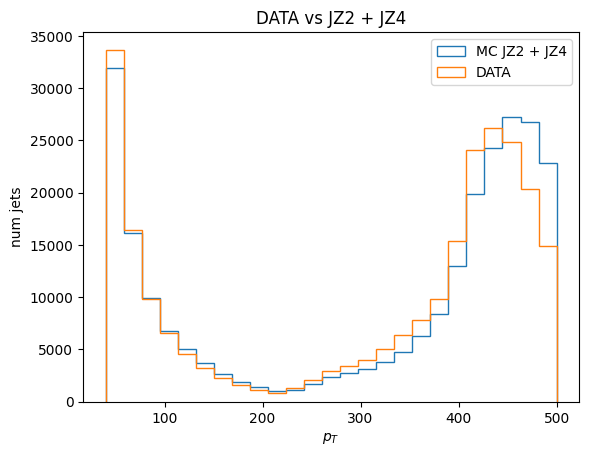

In [51]:
plt.hist(comb_jz4_000_009_jz2[:248703].pt, histtype='step', bins=25, label="MC JZ2 + JZ4")
plt.hist(data_ds.pt, histtype='step', bins=25, label="DATA")
plt.legend()
plt.xlabel("$p_T$")
plt.ylabel("num jets")
plt.title("DATA vs JZ2 + JZ4")
plt.show()

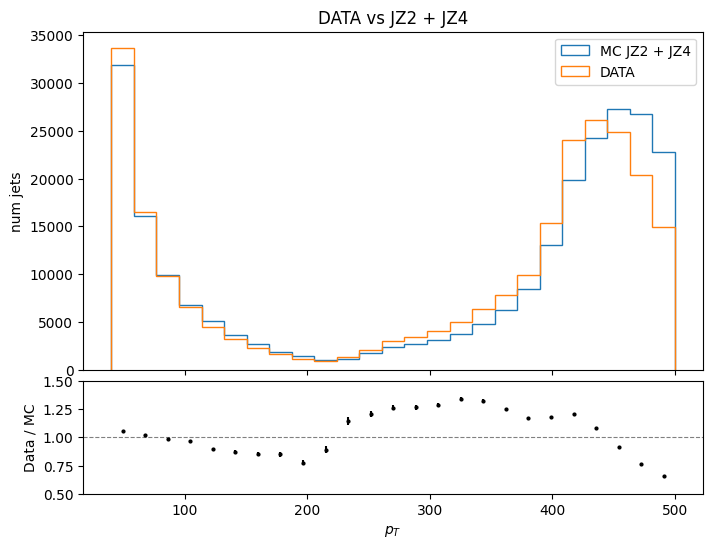

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# --- compute histograms with a shared binning ---
bins = 25
mc_vals = np.asarray(comb_jz4_000_009_jz2[:248703].pt)
data_vals = np.asarray(data_ds.pt)

bin_range = (min(mc_vals.min(), data_vals.min()),
             max(mc_vals.max(), data_vals.max()))

mc_counts,   bin_edges = np.histogram(mc_vals,   bins=bins, range=bin_range)
data_counts, _         = np.histogram(data_vals, bins=bin_edges)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# --- ratio + Poisson uncertainty on data ---
with np.errstate(divide='ignore', invalid='ignore'):
    ratio      = np.where(mc_counts > 0, data_counts / mc_counts, np.nan)
    ratio_err  = np.where(mc_counts > 0, np.sqrt(data_counts) / mc_counts, np.nan)

# --- two-panel figure ---
fig = plt.figure(figsize=(8, 6))
gs  = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.05)

ax_top = fig.add_subplot(gs[0])
ax_bot = fig.add_subplot(gs[1], sharex=ax_top)

# top: overlay histograms (re-plot from pre-computed counts so bins match)
ax_top.hist(bin_edges[:-1], bin_edges, weights=mc_counts,   histtype='step', label="MC JZ2 + JZ4")
ax_top.hist(bin_edges[:-1], bin_edges, weights=data_counts, histtype='step', label="DATA")
ax_top.legend()
ax_top.set_ylabel("num jets")
ax_top.set_title("DATA vs JZ2 + JZ4")
plt.setp(ax_top.get_xticklabels(), visible=False)  # shared x-axis, hide top labels

# bottom: ratio
ax_bot.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)
ax_bot.errorbar(bin_centers, ratio, yerr=ratio_err, fmt='k.', markersize=4)
ax_bot.set_xlabel("$p_T$")
ax_bot.set_ylabel("Data / MC")
ax_bot.set_ylim(0.5, 1.5)  # adjust to your data

plt.show()


## Decoding where the jets are from in JZ2

The JZ2 jets contain only 70 jets after they go through the cuts. We would expect basically 0 to make it through a J400 trigger. We are trying to figure out what is causing the jets to actually make it through the cut

In [15]:
jz2_with_truth = ak.from_parquet("../jz2_000.parquet")

In [16]:
len(jz2_with_truth)

70

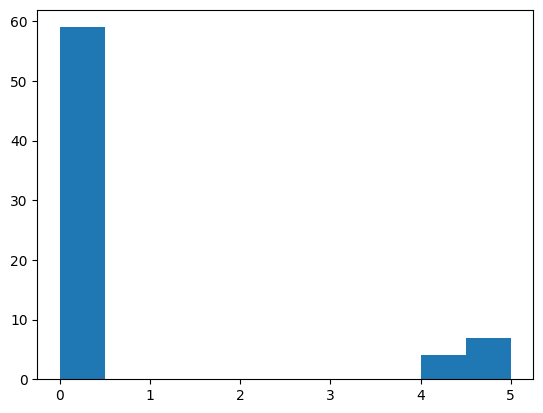

In [19]:
plt.hist(jz2_with_truth.jet_truthLabelID)
plt.show()